# Gradient Descent

This notebook develops **gradient descent (GD)** from first principles. We begin with the *gradient flow* ODE — the natural continuous-time steepest-descent process — and show that the discrete GD update rule is exactly **Euler's method** applied to that ODE. We then study learning rate sensitivity on non-convex landscapes and apply GD to least-squares regression.

## The Optimization Problem

Given a differentiable function $f : \mathbb{R}^n \to \mathbb{R}$, we seek a **local minimizer**

$$x^* = \underset{x \in \mathbb{R}^n}{\arg\min}\; f(x)$$

A necessary condition (when $f$ is differentiable) is that the gradient vanishes at $x^*$:

$$\nabla f(x^*) = 0$$

Points satisfying this are called **critical points** — they include local minima, local maxima, and saddle points. In high dimensions with non-convex $f$, there may be exponentially many critical points, all accessible only through local gradient information.

## Gradient Flow: The Continuous-Time View

*(Recall from Unit 4: an autonomous ODE $\dot{x} = g(x)$ is a dynamical system whose rate of change is determined entirely by the current state.)*

The natural continuous-time descent is the **gradient flow ODE**:

$$\boxed{\dot{x}(t) = -\nabla f(x(t))}$$

The state $x(t)$ moves in the direction of steepest descent at every instant.

## From Gradient Flow to Gradient Descent

Applying **forward Euler** (step size $\eta > 0$) to $\dot{x} = -\nabla f(x)$:

$$x_{k+1} = x_k + \eta\cdot(-\nabla f(x_k))$$

$$\boxed{x_{k+1} = x_k - \eta\,\nabla f(x_k)}$$

This is the **gradient descent update rule**. The step size $\eta$ is the Euler step and is called the **learning rate** in machine learning.

- **$\eta$ too small** → slow convergence (many iterations)
- **$\eta$ too large** → overshooting, potential divergence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use('dark_background')
np.random.seed(42)


def gradient_descent(grad_f, x0, eta, n_steps, tol=1e-9):
    """
    Gradient descent: x_{k+1} = x_k - eta * grad_f(x_k).

    Parameters
    ----------
    grad_f  : callable(x) -> ndarray
    x0      : array-like, starting point
    eta     : float, learning rate
    n_steps : int, maximum iterations
    tol     : float, stop when ||grad_f|| < tol

    Returns
    -------
    history : list of np.ndarray iterates
    """
    x = np.asarray(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_steps):
        g = np.asarray(grad_f(x), dtype=float)
        if np.linalg.norm(g) < tol:
            break
        x = x - eta * g
        history.append(x.copy())
    return history


def plot_slope_field_1d(df, x_range, t_range, ax, n=22, color='cyan', alpha=0.40):
    """
    Draw a 1-D slope field for the gradient flow dx/dt = -df(x).

    Horizontal axis = pseudo-time (iteration index), vertical = x.
    Matches the slope-field convention from the Unit 4 ODE notebooks.
    """
    t_vals = np.linspace(*t_range, n)
    x_vals = np.linspace(*x_range, n)
    T, X = np.meshgrid(t_vals, x_vals)
    DX = -df(X)
    DT = np.ones_like(DX)
    length = np.sqrt(DT**2 + DX**2)
    length[length == 0] = 1.0
    ax.quiver(T, X, DT / length, DX / length,
              alpha=alpha, color=color,
              headlength=0, headaxislength=0,
              pivot='middle', scale=n * 1.5)


## Toy 1D Landscape: Multiple Starting Points

Set `FUNCTION_CHOICE` (1–4) in the code cell below to select a test function. Each row shows gradient descent from a different starting point: landscape + trajectory (left), parameter history (center), convergence curve (right).

| Choice | Function | Character |
|--------|----------|-----------|
| 1 | $f(x) = x^2 - 3\\cos(10x)$ | Many local minima |
| 2 | $f(x) = (x^2 - 1)^2$ | Symmetric double well |
| 3 | $f(x) = \\sin(x) + 0.1x^2$ | Periodic with drift |
| 4 | $f(x) = x^4 - 4x^2 + x$ | Quartic polynomial |

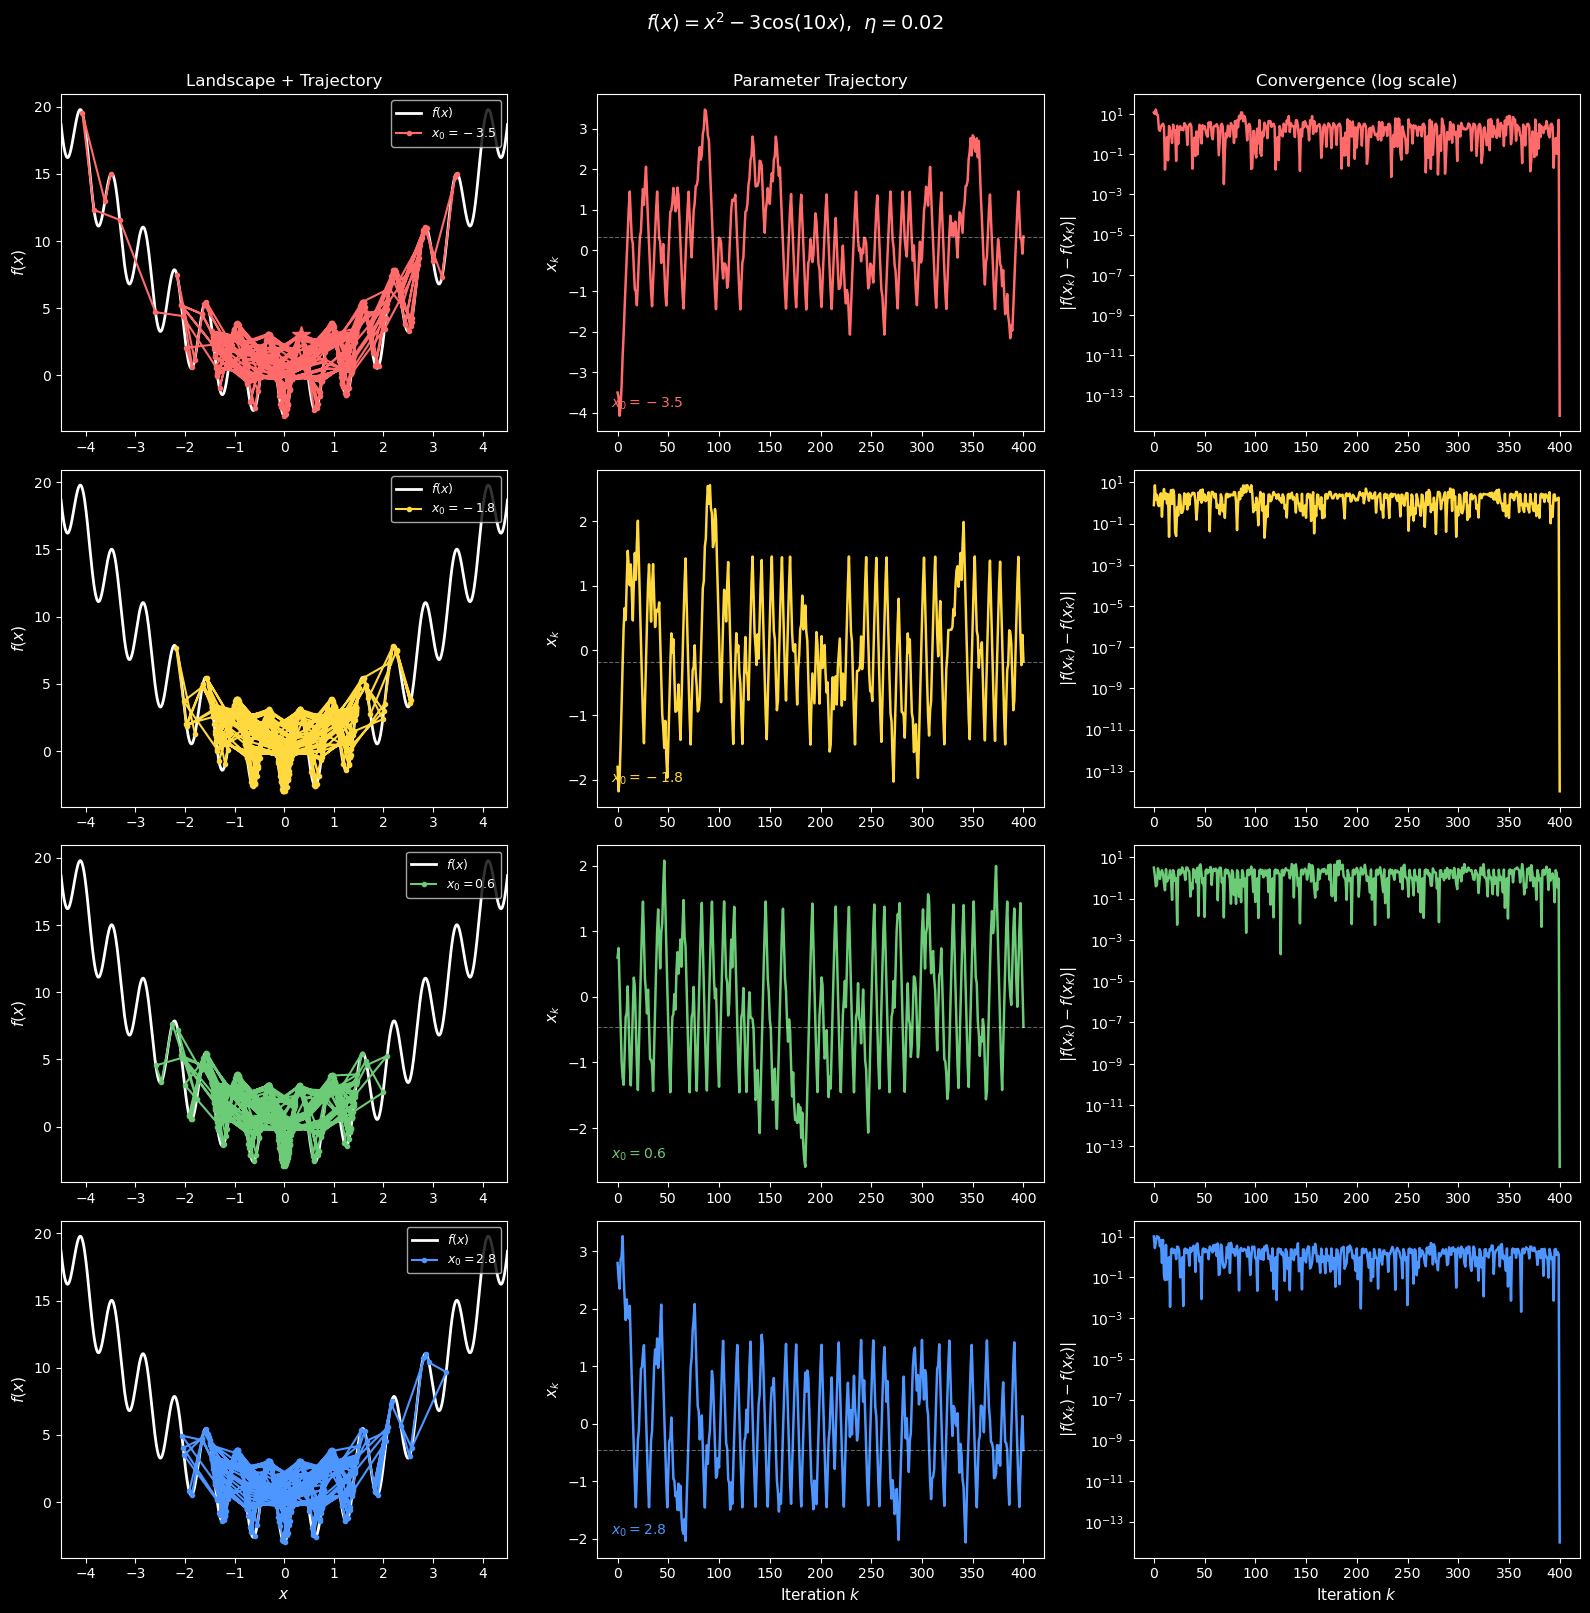

In [14]:
FUNCTIONS_1D = {
    1: dict(
        f       = lambda x: x**2 - 3 * np.cos(10 * x),
        df      = lambda x: 2 * x + 30 * np.sin(10 * x),
        label   = r'$f(x) = x^2 - 3\cos(10x)$',
        x_range = (-4.5, 4.5),
        starts  = [-3.5, -1.8, 0.6, 2.8],
        eta     = 0.02,
        n_steps = 400,
    ),
    2: dict(
        f       = lambda x: (x**2 - 1)**2,
        df      = lambda x: 4 * x * (x**2 - 1),
        label   = r'$f(x) = (x^2 - 1)^2$',
        x_range = (-2.5, 2.5),
        starts  = [-2.2, -0.5, 0.5, 2.2],
        eta     = 0.05,
        n_steps = 200,
    ),
    3: dict(
        f       = lambda x: np.sin(x) + 0.1 * x**2,
        df      = lambda x: np.cos(x) + 0.2 * x,
        label   = r'$f(x) = \sin(x) + 0.1x^2$',
        x_range = (-8.0, 8.0),
        starts  = [-7.0, -3.0, 1.0, 5.5],
        eta     = 0.05,
        n_steps = 300,
    ),
    4: dict(
        f       = lambda x: x**4 - 4 * x**2 + x,
        df      = lambda x: 4 * x**3 - 8 * x + 1,
        label   = r'$f(x) = x^4 - 4x^2 + x$',
        x_range = (-2.5, 2.5),
        starts  = [-2.3, -1.0, 0.5, 2.3],
        eta     = 0.03,
        n_steps = 300,
    ),
}

# ── Choose 1, 2, 3, or 4 ──────────────────────────────────────────────────────
FUNCTION_CHOICE = 1

cfg     = FUNCTIONS_1D[FUNCTION_CHOICE]
f1d     = cfg['f'];  df1d = cfg['df']
x_range = cfg['x_range']
starts  = cfg['starts']
eta_1d  = cfg['eta'];  n_steps_1d = cfg['n_steps']

x_grid = np.linspace(*x_range, 1000)
colors = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF']

histories_1d = [
    gradient_descent(lambda x, x0=x0: np.array([df1d(x[0])]),
                     [x0], eta_1d, n_steps_1d)
    for x0 in starts
]

n_rows = len(starts)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
fig.suptitle(f'{cfg["label"]},  $\\eta = {eta_1d}$', fontsize=14, y=1.005)

for row, (x0, hist, col) in enumerate(zip(starts, histories_1d, colors)):
    xs_t = np.array([h[0] for h in hist])
    fs_t = f1d(xs_t)

    # Left: landscape + trajectory
    ax = axes[row, 0]
    ax.plot(x_grid, f1d(x_grid), 'w-', lw=2, label='$f(x)$', zorder=1)
    ax.plot(xs_t, fs_t, 'o-', color=col, ms=3, lw=1.5, label=f'$x_0 = {x0}$')
    ax.plot(xs_t[-1], fs_t[-1], '*', color=col, ms=13, zorder=5)
    ax.set_xlim(*x_range)
    ax.set_ylabel('$f(x)$', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    if row == 0:
        ax.set_title('Landscape + Trajectory', fontsize=12)

    # Center: parameter vs iteration
    ax = axes[row, 1]
    ax.plot(xs_t, '-', color=col, lw=1.8)
    ax.axhline(xs_t[-1], color='white', lw=0.8, ls='--', alpha=0.4)
    ax.set_ylabel('$x_k$', fontsize=11)
    ax.text(0.03, 0.07, f'$x_0 = {x0}$', transform=ax.transAxes,
            fontsize=10, color=col)
    if row == 0:
        ax.set_title('Parameter Trajectory', fontsize=12)

    # Right: convergence (log scale)
    ax = axes[row, 2]
    fv = np.abs(fs_t - fs_t[-1]) + 1e-14
    ax.semilogy(fv, '-', color=col, lw=1.8)
    ax.set_ylabel('$|f(x_k) - f(x_K)|$', fontsize=11)
    if row == 0:
        ax.set_title('Convergence (log scale)', fontsize=12)

    if row == n_rows - 1:
        axes[row, 0].set_xlabel('$x$', fontsize=11)
        axes[row, 1].set_xlabel('Iteration $k$', fontsize=11)
        axes[row, 2].set_xlabel('Iteration $k$', fontsize=11)

plt.tight_layout()
plt.show()


## Learning Rate Sensitivity

All runs use the same starting point `x0_lr` (the first entry in `starts`). Each row shows a different learning rate: too small, good, large, and unstable. The three-panel layout makes it easy to compare trajectories, parameter histories, and objective values.

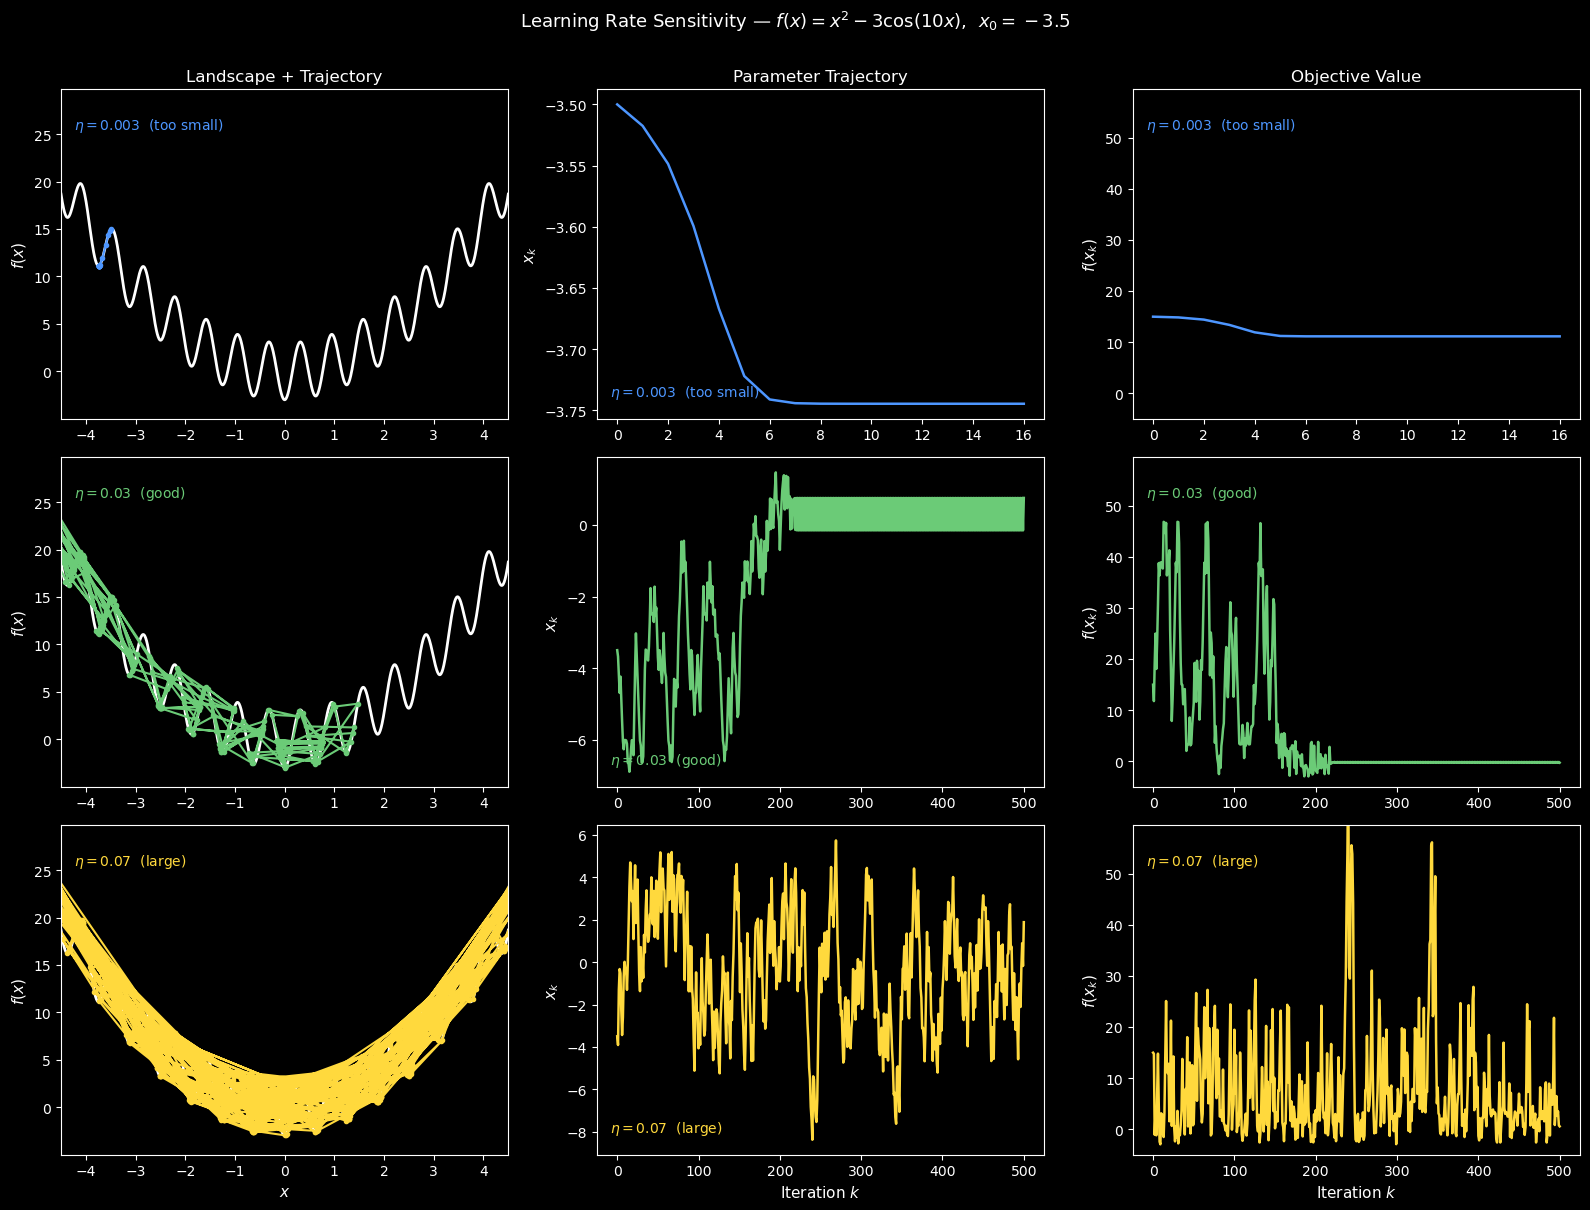

In [15]:
# ── Choose 1, 2, 3, or 4 ──────────────────────────────────────────────────────
FUNCTION_CHOICE = 1

LR_CONFIGS = {
    1: dict(etas=[0.003, 0.03,  0.07],
            notes=['too small', 'good', 'large']),
    2: dict(etas=[0.005, 0.05,  0.20],
            notes=['too small', 'good', 'large']),
    3: dict(etas=[0.01,  0.05,  0.20],
            notes=['too small', 'good', 'large']),
    4: dict(etas=[0.005, 0.03,  0.10],
            notes=['too small', 'good', 'large']),
}

x0_lr   = starts[0]
lr_cfg  = LR_CONFIGS[FUNCTION_CHOICE]
etas_lr = lr_cfg['etas']
notes   = lr_cfg['notes']
cols_lr = ['#4D96FF', '#6BCB77', '#FFD93D', '#FF6B6B']

histories_lr = [
    gradient_descent(lambda x, e=e: np.array([df1d(x[0])]),
                     [x0_lr], e, 500)
    for e in etas_lr
]

# y-axis bounds based on the function (not the unstable trajectory)
y_lo = f1d(x_grid).min() - 2
y_hi = f1d(x_grid).max() * 1.4 + 2

n_rows_lr = len(etas_lr)
fig, axes = plt.subplots(n_rows_lr, 3, figsize=(16, 4 * n_rows_lr))
fig.suptitle(
    f'Learning Rate Sensitivity — {cfg["label"]},  $x_0 = {x0_lr}$',
    fontsize=13, y=1.005
)

for row, (e, hist, col, note) in enumerate(
        zip(etas_lr, histories_lr, cols_lr, notes)):
    xs_t   = np.array([h[0] for h in hist])
    fs_raw = f1d(xs_t)
    tag    = f'$\\eta = {e}$  ({note})'

    # Left: landscape + trajectory (clipped for display)
    ax = axes[row, 0]
    ax.plot(x_grid, f1d(x_grid), 'w-', lw=2, zorder=1)
    ax.plot(xs_t, np.clip(fs_raw, y_lo - 5, y_hi * 4), 'o-', color=col, ms=3, lw=1.5)
    ax.set_xlim(*x_range); ax.set_ylim(y_lo, y_hi)
    ax.set_ylabel('$f(x)$', fontsize=11)
    ax.text(0.03, 0.92, tag, transform=ax.transAxes, fontsize=10, color=col, va='top')
    if row == 0:
        ax.set_title('Landscape + Trajectory', fontsize=12)

    # Center: parameter history
    ax = axes[row, 1]
    x_clip = (x_range[0] * 2.5, x_range[1] * 2.5)
    ax.plot(np.clip(xs_t, *x_clip), '-', color=col, lw=1.8)
    ax.set_ylabel('$x_k$', fontsize=11)
    ax.text(0.03, 0.07, tag, transform=ax.transAxes, fontsize=10, color=col)
    if row == 0:
        ax.set_title('Parameter Trajectory', fontsize=12)

    # Right: objective value (linear, clipped)
    ax = axes[row, 2]
    ax.plot(np.clip(fs_raw, y_lo - 5, y_hi * 8), '-', color=col, lw=1.8)
    ax.set_ylim(y_lo, y_hi * 2)
    ax.set_ylabel('$f(x_k)$', fontsize=11)
    ax.text(0.03, 0.92, tag, transform=ax.transAxes, fontsize=10, color=col, va='top')
    if row == 0:
        ax.set_title('Objective Value', fontsize=12)

    if row == n_rows_lr - 1:
        axes[row, 0].set_xlabel('$x$', fontsize=11)
        axes[row, 1].set_xlabel('Iteration $k$', fontsize=11)
        axes[row, 2].set_xlabel('Iteration $k$', fontsize=11)

plt.tight_layout()
plt.show()


## Application: Least Squares

### 1D Linear Regression

Given observations $(x_i, y_i)$ with

$$\hat y_i = m x_i + b$$

we minimize the sum of squared errors:

$$\mathcal{L}(m, b) = \sum_{i=1}^{N} (y_i - m x_i - b)^2$$

The gradients are:

$$\frac{\partial \mathcal{L}}{\partial m} = -2\sum_i x_i(y_i - m x_i - b), \qquad \frac{\partial \mathcal{L}}{\partial b} = -2\sum_i (y_i - m x_i - b)$$

This loss is **convex** in $(m, b)$, so GD converges to the global minimum — identical to the analytical OLS solution from the normal equations.

<>:36: SyntaxWarning: invalid escape sequence '\,'
<>:38: SyntaxWarning: invalid escape sequence '\,'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\,'
<>:38: SyntaxWarning: invalid escape sequence '\,'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\2528850015.py:36: SyntaxWarning: invalid escape sequence '\,'
  label=f'GD  $m={m_gd:.3f},\, b={b_gd:.3f}$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\2528850015.py:38: SyntaxWarning: invalid escape sequence '\,'
  label=f'OLS  $m={m_ols:.3f},\, b={b_ols:.3f}$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\2528850015.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(cs2, ax=ax, label='$\mathcal{L}(m,b)$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\2528850015.py:55: SyntaxWarnin

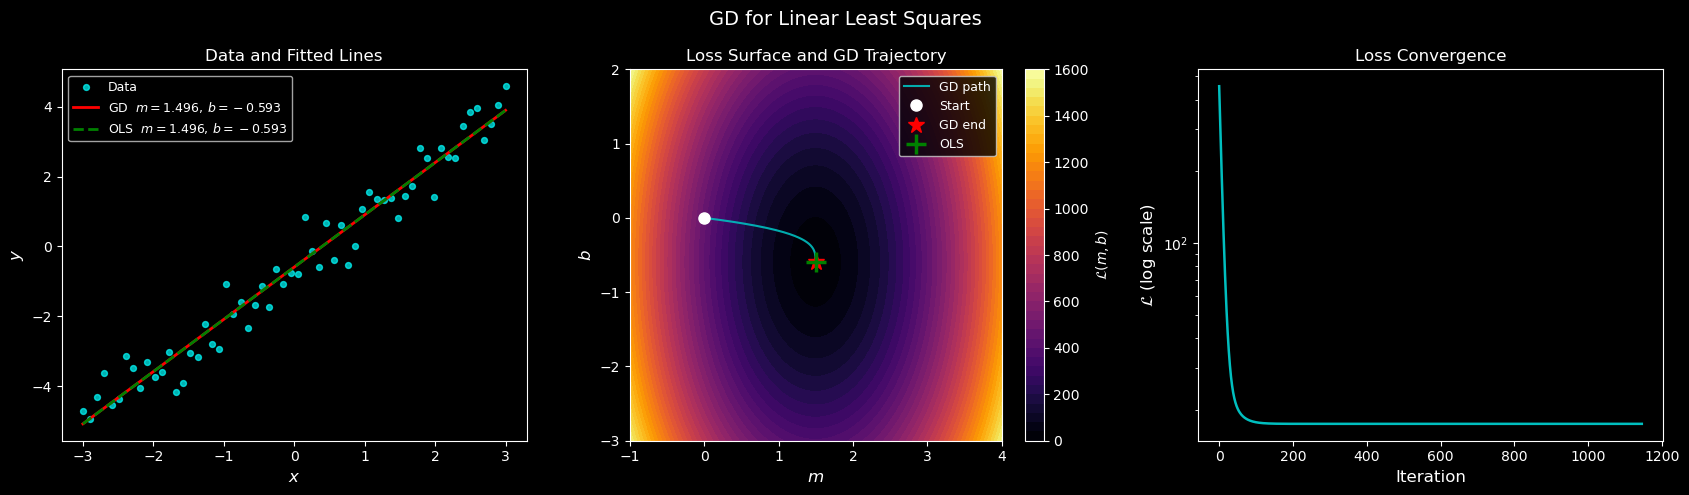

GD:   m = 1.49579,  b = -0.59279
OLS:  m = 1.49579,  b = -0.59279
True: m = 1.50000,  b = -0.50000


In [4]:
N = 60
x_data = np.linspace(-3, 3, N)
m_true, b_true = 1.5, -0.5
y_data = m_true * x_data + b_true + 0.6 * np.random.randn(N)

def grad_linear(params):
    m, b = params
    resid = y_data - m * x_data - b
    return np.array([-2 * np.dot(x_data, resid), -2 * np.sum(resid)])

def loss_linear(params):
    m, b = params
    return np.sum((y_data - m * x_data - b)**2)

# Analytical OLS
X_mat = np.column_stack([x_data, np.ones(N)])
m_ols, b_ols = np.linalg.lstsq(X_mat, y_data, rcond=None)[0]

# GD
params0 = np.array([0.0, 0.0])
eta_lin = 1.8e-4
hist_lin = gradient_descent(grad_linear, params0, eta_lin, 3000)
traj_lin = np.array(hist_lin)
m_gd, b_gd = traj_lin[-1]

# Loss surface
mv = np.linspace(-1, 4, 200); bv = np.linspace(-3, 2, 200)
Mv, Bv = np.meshgrid(mv, bv)
Lv = np.array([[loss_linear([m, b]) for m in mv] for b in bv])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.scatter(x_data, y_data, color='cyan', s=18, alpha=0.7, label='Data')
ax.plot(x_data, m_gd * x_data + b_gd, 'r-', lw=2,
        label=f'GD  $m={m_gd:.3f},\, b={b_gd:.3f}$')
ax.plot(x_data, m_ols * x_data + b_ols, 'g--', lw=2,
        label=f'OLS  $m={m_ols:.3f},\, b={b_ols:.3f}$')
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$y$', fontsize=12)
ax.set_title('Data and Fitted Lines', fontsize=12); ax.legend(fontsize=9)

ax = axes[1]
cs2 = ax.contourf(Mv, Bv, Lv, levels=40, cmap='inferno')
plt.colorbar(cs2, ax=ax, label='$\mathcal{L}(m,b)$')
ax.plot(traj_lin[:, 0], traj_lin[:, 1], 'c-', lw=1.5, alpha=0.9, label='GD path')
ax.plot(*params0, 'wo', ms=8, label='Start')
ax.plot(m_gd, b_gd, 'r*', ms=12, label='GD end')
ax.plot(m_ols, b_ols, 'g+', ms=14, mew=2.5, label='OLS')
ax.set_xlabel('$m$', fontsize=12); ax.set_ylabel('$b$', fontsize=12)
ax.set_title('Loss Surface and GD Trajectory', fontsize=12); ax.legend(fontsize=9)

ax = axes[2]
losses_lin = [loss_linear(p) for p in traj_lin]
ax.semilogy(losses_lin, 'c-', lw=1.8)
ax.set_xlabel('Iteration', fontsize=12); ax.set_ylabel('$\mathcal{L}$ (log scale)', fontsize=12)
ax.set_title('Loss Convergence', fontsize=12)

plt.suptitle('GD for Linear Least Squares', fontsize=14)
plt.tight_layout(); plt.show()

print(f'GD:   m = {m_gd:.5f},  b = {b_gd:.5f}')
print(f'OLS:  m = {m_ols:.5f},  b = {b_ols:.5f}')
print(f'True: m = {m_true:.5f},  b = {b_true:.5f}')


### Nonlinear Least Squares: Exponential Fit

If we fit a mpm;omear function like

$$\hat y_i = a \cdot e^{b x_i}$$

to data, the loss $\mathcal{L}(a,b)$ is **non-convex** — no closed-form solution exists, and GD may reach different local minima depending on initialization. The gradients follow from the chain rule:

$$\frac{\partial \mathcal{L}}{\partial a} = -2\sum_i e^{bx_i}\,(y_i - a e^{bx_i}), \qquad \frac{\partial \mathcal{L}}{\partial b} = -2\sum_i ax_i e^{bx_i}\,(y_i - a e^{bx_i})$$

<>:31: SyntaxWarning: invalid escape sequence '\,'
<>:33: SyntaxWarning: invalid escape sequence '\,'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\,'
<>:33: SyntaxWarning: invalid escape sequence '\,'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\303193322.py:31: SyntaxWarning: invalid escape sequence '\,'
  label=f'GD  $a={a_gd_nl:.3f},\, b={b_gd_nl:.3f}$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\303193322.py:33: SyntaxWarning: invalid escape sequence '\,'
  label=f'True  $a={a_true},\, b={b_true_nl}$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\303193322.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.colorbar(cs3, ax=ax, label='$\log(1 + \mathcal{L})$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_28644\303193322.py:49: SyntaxW

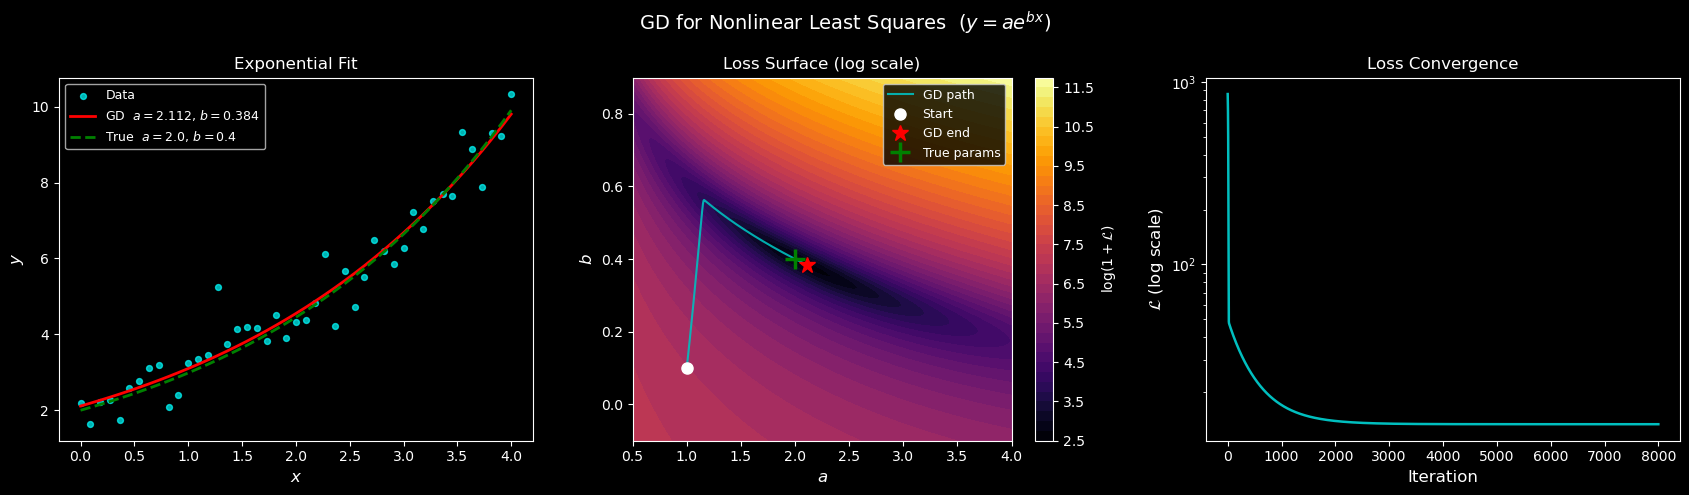

GD:   a = 2.11152,  b = 0.38382
True: a = 2.00000,  b = 0.40000


In [18]:
a_true, b_true_nl = 2.0, 0.4
x_nl = np.linspace(0, 4, 45)
y_nl = a_true * np.exp(b_true_nl * x_nl) + 0.5 * np.random.randn(45)

def grad_exp(params):
    a, b = params
    pred  = a * np.exp(b * x_nl)
    resid = y_nl - pred
    da = -2 * np.dot(np.exp(b * x_nl), resid)
    db = -2 * np.dot(a * x_nl * np.exp(b * x_nl), resid)
    return np.array([da, db])

def loss_exp(params):
    a, b = params
    return np.sum((y_nl - a * np.exp(b * x_nl))**2)

params0_nl = np.array([1.0, 0.1])
hist_nl = gradient_descent(grad_exp, params0_nl, 1.5e-5, 8000)
traj_nl = np.array(hist_nl)
a_gd_nl, b_gd_nl = traj_nl[-1]

av = np.linspace(0.5, 4.0, 200); bv_nl = np.linspace(-0.1, 0.9, 200)
Av, Bnl = np.meshgrid(av, bv_nl)
Lv_nl = np.array([[loss_exp([a, b]) for a in av] for b in bv_nl])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.scatter(x_nl, y_nl, color='cyan', s=18, alpha=0.7, label='Data')
ax.plot(x_nl, a_gd_nl * np.exp(b_gd_nl * x_nl), 'r-', lw=2,
        label=f'GD  $a={a_gd_nl:.3f},\, b={b_gd_nl:.3f}$')
ax.plot(x_nl, a_true * np.exp(b_true_nl * x_nl), 'g--', lw=2,
        label=f'True  $a={a_true},\, b={b_true_nl}$')
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$y$', fontsize=12)
ax.set_title('Exponential Fit', fontsize=12); ax.legend(fontsize=9)

ax = axes[1]
cs3 = ax.contourf(Av, Bnl, np.log1p(Lv_nl), levels=40, cmap='inferno')
plt.colorbar(cs3, ax=ax, label='$\log(1 + \mathcal{L})$')
ax.plot(traj_nl[:, 0], traj_nl[:, 1], 'c-', lw=1.5, alpha=0.9, label='GD path')
ax.plot(*params0_nl, 'wo', ms=8, label='Start')
ax.plot(a_gd_nl, b_gd_nl, 'r*', ms=12, label='GD end')
ax.plot(a_true, b_true_nl, 'g+', ms=14, mew=2.5, label='True params')
ax.set_xlabel('$a$', fontsize=12); ax.set_ylabel('$b$', fontsize=12)
ax.set_title('Loss Surface (log scale)', fontsize=12); ax.legend(fontsize=9)

ax = axes[2]
ax.semilogy([loss_exp(p) for p in traj_nl], 'c-', lw=1.8)
ax.set_xlabel('Iteration', fontsize=12); ax.set_ylabel('$\mathcal{L}$ (log scale)', fontsize=12)
ax.set_title('Loss Convergence', fontsize=12)

plt.suptitle(r'GD for Nonlinear Least Squares  ($y = ae^{bx}$)', fontsize=14)
plt.tight_layout(); plt.show()

print(f'GD:   a = {a_gd_nl:.5f},  b = {b_gd_nl:.5f}')
print(f'True: a = {a_true:.5f},  b = {b_true_nl:.5f}')


## Summary

- The **gradient flow ODE** $\dot{x} = -\nabla f(x)$ is a continuous steepest-descent dynamical system; $f$ decreases monotonically along every trajectory.
- **Gradient descent** is **Euler's method** applied to gradient flow: $x_{k+1} = x_k - \eta\,\nabla f(x_k)$, where the learning rate $\eta$ plays the role of the step size $h$.
- Stability requires $\eta < 2/L$; the optimal rate for smooth strongly convex problems is $\eta = 1/L$.
- On **non-convex landscapes**, GD finds the local minimum nearest its starting point — global search requires different methods (see *Simulated Annealing*).
- On **ill-conditioned problems** (elongated valleys), GD zigzags inefficiently — adding momentum cures this (see *Gradient Descent with Momentum*).
- GD converges to the OLS solution on convex least-squares problems; on non-convex problems the result depends on initialization.